In [2]:
import csv
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

def loadData(fileName, inputVarNames, outputVarName):
    data = []
    header = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        for i, row in enumerate(csv_reader):
            if i == 0:
                header = row
            else:
                data.append(row)

    inputIndices = [header.index(var) for var in inputVarNames]
    outputIndex = header.index(outputVarName)

    inputs = [[float(row[i]) for i in inputIndices] for row in data]
    outputs = [float(row[outputIndex]) for row in data]
    return inputs, outputs


In [4]:
crtDir = os.getcwd()
filePath = os.path.join(crtDir, 'data', 'v1_world-happiness-report-2017.csv')

inputs_uni, outputs_uni = loadData(filePath, ['Family'], 'Happiness.Score')


In [5]:
np.random.seed(1)
indexes = list(range(len(inputs_uni)))
train_idx = np.random.choice(indexes, int(0.8 * len(inputs_uni)), replace=False)
test_idx = [i for i in indexes if i not in train_idx]

trainInputs = [inputs_uni[i] for i in train_idx]
trainOutputs = [outputs_uni[i] for i in train_idx]
testInputs = [inputs_uni[i] for i in test_idx]
testOutputs = [outputs_uni[i] for i in test_idx]


In [6]:
regressor = linear_model.LinearRegression()
regressor.fit(trainInputs, trainOutputs)

w0 = regressor.intercept_
w1 = regressor.coef_[0]

print(f"Model învățat: f(x) = {w0:.4f} + {w1:.4f} * Family")


Model învățat: f(x) = -1.3731 + 4.4452 * Family


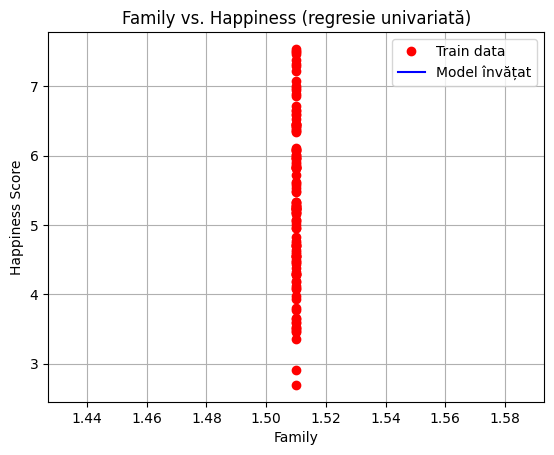

In [7]:
x_vals = [row[0] for row in trainInputs]
plt.plot(x_vals, trainOutputs, 'ro', label='Train data')

x_line = np.linspace(min(x_vals), max(x_vals), 100)
y_line = w0 + w1 * x_line
plt.plot(x_line, y_line, 'b-', label='Model învățat')

plt.title("Family vs. Happiness (regresie univariată)")
plt.xlabel("Family")
plt.ylabel("Happiness Score")
plt.legend()
plt.grid()
plt.show()


In [8]:
predictedOutputs = regressor.predict(testInputs)

error = mean_squared_error(testOutputs, predictedOutputs)
print(f"Eroare MSE pe datele de testare: {error:.4f}")


Eroare MSE pe datele de testare: 1.2734


In [10]:
inputs_bi, outputs_bi = loadData(filePath, ['Economy..GDP.per.Capita.', 'Freedom'], 'Happiness.Score')


In [11]:
np.random.seed(1)
indexes = list(range(len(inputs_bi)))
train_idx = np.random.choice(indexes, int(0.8 * len(inputs_bi)), replace=False)
test_idx = [i for i in indexes if i not in train_idx]

trainInputs = [inputs_bi[i] for i in train_idx]
trainOutputs = [outputs_bi[i] for i in train_idx]
testInputs = [inputs_bi[i] for i in test_idx]
testOutputs = [outputs_bi[i] for i in test_idx]


In [12]:
regressor = linear_model.LinearRegression()
regressor.fit(trainInputs, trainOutputs)

w0 = regressor.intercept_
w1, w2 = regressor.coef_
print(f"Model învățat: f(x) = {w0:.4f} + {w1:.4f} * GDP + {w2:.4f} * Freedom")


Model învățat: f(x) = 2.4461 + 1.8692 * GDP + 2.6230 * Freedom


In [13]:
predictedOutputs = regressor.predict(testInputs)
error = mean_squared_error(testOutputs, predictedOutputs)
print(f"Eroare MSE pe test set (bivariat): {error:.4f}")



Eroare MSE pe test set (bivariat): 0.2244
